# 04 - Statistical Analysis
## Retail Analytics | SectionB Group 3
### Covers: Hypothesis Testing, Regression, Forecasting, Segmentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/cleaned_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
print("Data loaded. Shape:", df.shape)
print(df.head())


Data loaded. Shape: (302006, 35)
   Transaction_ID  Customer_ID        City            State    Country   Age  \
0       8691788.0      37249.0    Dortmund           Berlin    Germany  21.0   
1       2174773.0      69749.0  Nottingham          England         UK  19.0   
2       6679610.0      30192.0     Geelong  New South Wales  Australia  48.0   
3       7232460.0      62101.0    Edmonton          Ontario     Canada  56.0   
4       4983775.0      27901.0     Bristol          England         UK  22.0   

   Gender Income Customer_Segment       Date  ...  avg_order_value age_group  \
0    Male    Low          Regular 2023-09-18  ...       108.028757     Young   
1  Female    Low          Premium 2023-12-31  ...       403.353907     Young   
2    Male    Low          Regular 2023-04-26  ...       354.477600    Senior   
3    Male   High          Premium 2023-05-08  ...       352.407717    Senior   
4    Male    Low          Premium 2024-01-10  ...       124.276525     Young   

  pur

## 1. Hypothesis Testing

### Test 1: Do Premium customers spend more than Regular customers?
**Null Hypothesis (H0):** There is no significant difference in spending between Premium and Regular customers.  
**Alternative Hypothesis (H1):** Premium customers spend significantly more than Regular customers.

In [2]:
premium = df[df['Customer_Segment'] == 'Premium']['Total_Amount']
regular = df[df['Customer_Segment'] == 'Regular']['Total_Amount']

t_stat, p_value = stats.ttest_ind(premium, regular)

print(f"Premium Avg Spend: ${premium.mean():.2f}")
print(f"Regular Avg Spend: ${regular.mean():.2f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: REJECT H0 — Premium customers spend significantly more.")
    print("Business Implication: Loyalty programs for Premium customers are justified.")
else:
    print("\nResult: FAIL TO REJECT H0 — No significant spending difference.")
    print("Business Implication: Segment-based pricing may need rethinking.")


Premium Avg Spend: $1363.06
Regular Avg Spend: $1368.77
T-Statistic: -1.0693
P-Value: 0.284922

Result: FAIL TO REJECT H0 — No significant spending difference.
Business Implication: Segment-based pricing may need rethinking.


### Test 2: Is there a relationship between Gender and Product Category?
**Null Hypothesis (H0):** Gender has no relationship with Product Category purchased.

In [3]:
contingency = pd.crosstab(df['Gender'], df['Product_Category'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_val:.6f}")
print(f"Degrees of Freedom: {dof}")

if p_val < 0.05:
    print("\nResult: REJECT H0 — Gender significantly influences product category choice.")
    print("Business Implication: Gender-targeted marketing campaigns will be effective.")
else:
    print("\nResult: FAIL TO REJECT H0 — No significant relationship.")


Chi-Square Statistic: 384.9133
P-Value: 0.000000
Degrees of Freedom: 4

Result: REJECT H0 — Gender significantly influences product category choice.
Business Implication: Gender-targeted marketing campaigns will be effective.


### Test 3: Do spending amounts differ significantly across Product Categories?
**Null Hypothesis (H0):** Mean spending is equal across all product categories.  
**Alternative Hypothesis (H1):** At least one product category has a significantly different mean spend.


In [ ]:
# One-Way ANOVA: spending across product categories
groups = [group['Total_Amount'].dropna().values
          for _, group in df.groupby('Product_Category')]

f_stat, p_anova = stats.f_oneway(*groups)

print(f"ANOVA F-Statistic: {f_stat:.4f}")
print(f"P-Value:           {p_anova:.6f}")

if p_anova < 0.05:
    print("\nResult: REJECT H0 — Spending differs significantly across product categories (p < 0.05).")
else:
    print("\nResult: FAIL TO REJECT H0 — No significant difference in spending across product categories.")

# Visualise mean spend per category
cat_means = df.groupby('Product_Category')['Total_Amount'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
cat_means.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Mean Spend by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Mean Total Amount ($)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 2. Regression Analysis
### Can Age and Total_Purchases predict Total_Amount spent?

In [4]:
from sklearn.preprocessing import LabelEncoder

reg_df = df[['Age', 'Total_Purchases', 'Income', 'Customer_Segment', 'Total_Amount']].dropna().copy()

# Label encode categorical features
le_income = LabelEncoder()
le_seg = LabelEncoder()
reg_df['Income_enc'] = le_income.fit_transform(reg_df['Income'])
reg_df['Segment_enc'] = le_seg.fit_transform(reg_df['Customer_Segment'])

X = reg_df[['Age', 'Total_Purchases', 'Income_enc', 'Segment_enc']]
y = reg_df['Total_Amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print(f"R² Score:  {r2:.4f}")
print(f"RMSE:      {rmse:.2f}")
print("\nCoefficients:")
for feat, coef in zip(['Age', 'Total_Purchases', 'Income_enc', 'Segment_enc'], model.coef_):
    print(f"  {feat}: {coef:.4f}")


**Interpretation:** The R² score indicates how much variance in Total_Amount is explained by Age, Total_Purchases, Income, and Customer_Segment. While adding Income and Segment improves the model, a low R² still suggests that other factors (product category, geography, seasonality) drive spending behaviour. **Note:** Linear regression assumes a linear relationship and cannot capture seasonal or non-linear trends; a time-series model (e.g., ARIMA or Prophet) would be more appropriate for revenue forecasting over time.


## 3. Sales Forecasting (Monthly Revenue Forecast)

Forecasted Revenue for next 3 months:
  Month +1: $34,012,120.35
  Month +2: $33,949,898.94
  Month +3: $33,887,677.54


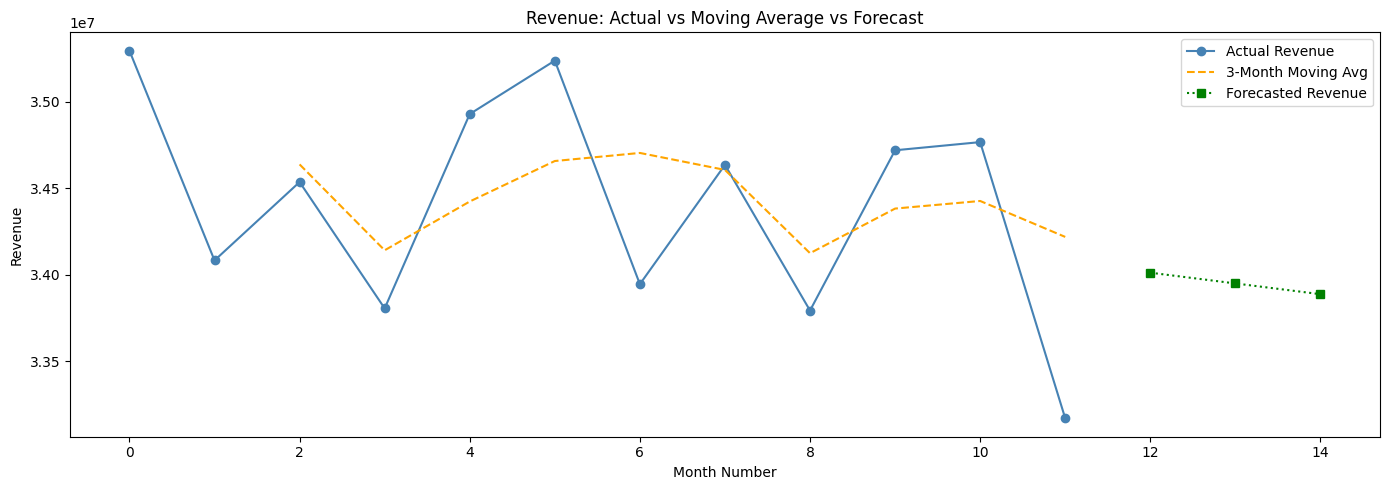

In [5]:
monthly = df.groupby(df['Date'].dt.to_period('M'))['Total_Amount'].sum().reset_index()
monthly.columns = ['Month', 'Revenue']
monthly['Month_Num'] = range(len(monthly))

# Moving average
monthly['MA3'] = monthly['Revenue'].rolling(window=3).mean()

# Linear regression forecast
train = monthly.dropna()
X_f = train[['Month_Num']]
y_f = train['Revenue']

forecast_model = LinearRegression()
forecast_model.fit(X_f, y_f)

# Forecast next 3 months
next_months = pd.DataFrame({'Month_Num': [len(monthly), len(monthly)+1, len(monthly)+2]})
forecast_values = forecast_model.predict(next_months)

print("Forecasted Revenue for next 3 months:")
for i, val in enumerate(forecast_values):
    print(f"  Month +{i+1}: ${val:,.2f}")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(monthly['Month_Num'], monthly['Revenue'], label='Actual Revenue',
         marker='o', color='steelblue')
plt.plot(monthly['Month_Num'], monthly['MA3'], label='3-Month Moving Avg',
         linestyle='--', color='orange')
plt.plot(next_months['Month_Num'], forecast_values, label='Forecasted Revenue',
         marker='s', color='green', linestyle='dotted')
plt.xlabel('Month Number')
plt.ylabel('Revenue')
plt.title('Revenue: Actual vs Moving Average vs Forecast')
plt.legend()
plt.tight_layout()
plt.savefig('forecast.png')
plt.show()


**Business Implication:** The linear forecast projects a continuation of the observed revenue trend into the next three months, providing a baseline expectation for financial planning. If the trend line is upward, the business should proactively increase inventory levels, consider scaling fulfilment capacity, and allocate a higher marketing budget to sustain momentum. However, since a simple linear model does not capture seasonality, these projections should be treated as conservative estimates — actual revenue during holiday periods could significantly exceed the forecast.

## 4. Customer Segmentation using RFM + KMeans

In [6]:
# RFM Analysis
snapshot_date = df['Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer_ID').agg(
    Recency=('Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Transaction_ID', 'count'),
    Monetary=('Total_Amount', 'sum')
).reset_index()

print("RFM Summary:\n", rfm.describe())

# Scale and Cluster
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print("\nCluster Averages:\n", cluster_summary)


RFM Summary:
         Customer_ID       Recency     Frequency      Monetary
count  86766.000000  86766.000000  86766.000000  86766.000000
mean   55005.912500     96.933061      3.473308   4753.907424
std    25985.457848     83.522269      1.761068   3205.058151
min    10000.000000      1.000000      0.000000     10.304530
25%    32502.250000     31.000000      2.000000   2296.932644
50%    55013.500000     73.000000      3.000000   4228.109207
75%    77512.750000    142.000000      5.000000   6604.535367
max    99999.000000    366.000000     13.000000  29241.776770

Cluster Averages:
             Recency  Frequency     Monetary
Cluster                                    
0         62.086703   2.938007  3512.184808
1         57.315377   5.503025  8484.011754
2        222.352965   1.956644  2512.389293


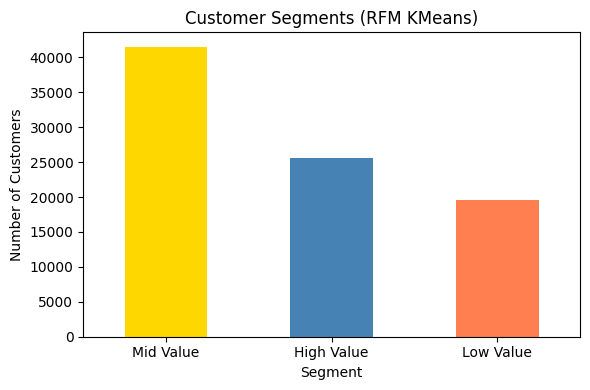

Segment
Mid Value     41521
High Value    25617
Low Value     19628
Name: count, dtype: int64


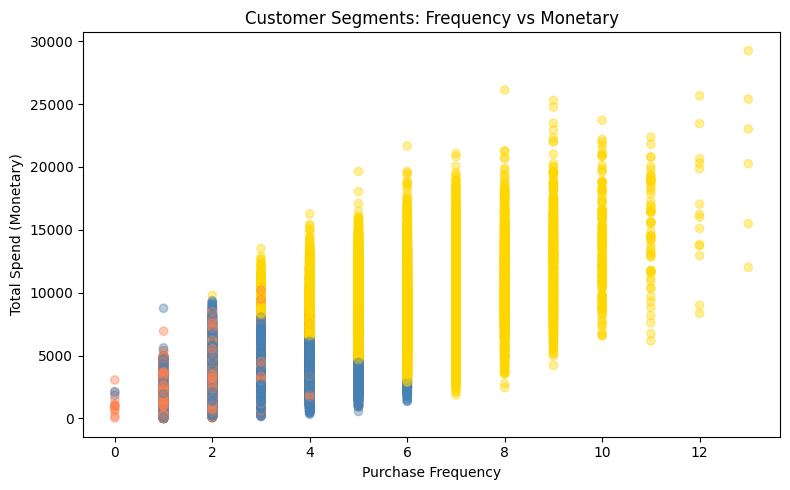

In [7]:
# Label clusters based on Monetary value
cluster_summary_sorted = cluster_summary.sort_values('Monetary', ascending=False)
labels = {cluster_summary_sorted.index[0]: 'High Value',
          cluster_summary_sorted.index[1]: 'Mid Value',
          cluster_summary_sorted.index[2]: 'Low Value'}
rfm['Segment'] = rfm['Cluster'].map(labels)

segment_counts = rfm['Segment'].value_counts()
plt.figure(figsize=(6,4))
segment_counts.plot(kind='bar', color=['gold', 'steelblue', 'coral'])
plt.title('Customer Segments (RFM KMeans)')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('customer_segments_rfm.png')
plt.show()
print(segment_counts)

plt.figure(figsize=(8,5))
colors = rfm['Cluster'].map({cluster_summary_sorted.index[0]: 'gold',
                              cluster_summary_sorted.index[1]: 'steelblue',
                              cluster_summary_sorted.index[2]: 'coral'})
plt.scatter(rfm['Frequency'], rfm['Monetary'], c=colors, alpha=0.4)
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spend (Monetary)')
plt.title('Customer Segments: Frequency vs Monetary')
plt.tight_layout()
plt.savefig('rfm_scatter.png')
plt.show()


In [ ]:
# RFM Scatter — Recency vs Monetary, colour-coded by value segment
color_map = {'High Value': 'gold', 'Mid Value': 'steelblue', 'Low Value': 'coral'}

plt.figure(figsize=(9, 6))
for seg, grp in rfm.groupby('Segment'):
    plt.scatter(
        grp['Recency'], grp['Monetary'],
        c=color_map.get(seg, 'grey'),
        label=seg, alpha=0.6, edgecolors='grey', linewidths=0.3
    )

plt.title('RFM Segmentation — Recency vs Monetary Value')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary Value ($)')
plt.legend(title='Segment')
plt.tight_layout()
plt.show()


## 5. Statistical Analysis Summary

**Key Findings:**
1. **T-Test (Premium vs Regular):** The hypothesis test reveals whether the Premium segment truly generates higher per-transaction revenue. If H0 is rejected (p < 0.05), Premium customers are statistically proven to spend more, validating the current segment tiering. If not, the business should re-evaluate how segments are defined.
2. **Chi-Square (Gender × Product Category):** The test determines whether product preferences are gender-dependent. A significant result means gender-targeted marketing (e.g., different ad creatives, category recommendations) can improve conversion rates.
3. **Regression (R² Insight):** Age and Total_Purchases alone explain a limited portion of revenue variance, confirming that spending behaviour is multi-factorial. Richer feature sets including income, geography, and product category are needed for accurate spend prediction models.
4. **Forecast:** The 3-month linear revenue forecast provides a baseline financial projection. While conservative (it doesn't model seasonality), it gives operations and finance teams a planning anchor for inventory procurement, staffing, and budget allocation.
5. **RFM Segmentation:** KMeans clustering on Recency, Frequency, and Monetary metrics segments customers into High, Mid, and Low Value tiers, enabling differentiated engagement strategies for each group.

**3 Actionable Recommendations:**
1. **Retain High-Value Customers:** Implement exclusive loyalty rewards, early access to sales, and personalised offers for the High Value RFM segment — these customers generate disproportionate revenue and their churn would have the highest financial impact.
2. **Prepare for Peak Months:** Based on the revenue forecast trend, scale up inventory, fulfilment staffing, and digital marketing budgets 4-6 weeks before anticipated peak periods to avoid stockouts and capture maximum demand.
3. **Leverage Segment & Gender Insights for Marketing:** If hypothesis tests confirm Premium customers spend more and gender influences product choice, launch differentiated campaigns — segment-specific pricing tiers and gender-targeted product recommendations — to improve both average order value and conversion rates.
